In [1]:
load_ext jupyter_black

In [2]:
import numpy as np
import pickle
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway
import pingouin as pg

In [3]:
demographics = {
    "prism": [
        "age",
        "gender",
        "employment_status",
        "education",
        "marital_status",
        "english_proficiency",
        "religion",
        "ethnicity",
        "birth_region",
        "reside_region",
        "lm_familiarity",
    ],
    "personamem": [
        "age",
        "ethnicity",
        "gender",
    ],
    "cad_en": [
        "annotator_age",
        "annotator_gender",
        "annotator_education_level",
        "annotator_political",
        "annotator_ethnicity",
    ],
}

domains = ["legal", "salary", "medical", "benefits", "political"]

In [4]:
def get_answers(model):
    questions = pd.read_pickle(f"data/{model}_questions.gz")
    questions_correct_answers = dict(zip(questions.q_id, questions.correct_answer))
    questions_baseline_answers = questions[["q_id", "baseline_answer", "domain"]]

    questions_baseline_answers = questions_baseline_answers.loc[
        ~questions_baseline_answers["q_id"].isin([f"q_{i}" for i in range(61)])
    ].reset_index(drop=True)

    domain_qid_map = {
        domain: questions.loc[questions["domain"] == domain, "q_id"].tolist()
        for domain in domains
    }

    questions_baseline_answers.loc[
        questions_baseline_answers["domain"] == "salary",
        "baseline_answer",
    ] = (
        questions_baseline_answers.loc[
            questions_baseline_answers["domain"] == "salary",
            "baseline_answer",
        ]
        .str.replace(",", "")
        .str.extract(r"^[^\d]*(\d+)", expand=False)
        .astype(float)
    )

    questions_baseline_answers = pd.Series(
        questions_baseline_answers.baseline_answer.values,
        index=questions_baseline_answers.q_id,
    ).to_dict()
    return domain_qid_map, questions_correct_answers, questions_baseline_answers

In [5]:
def get_stats(df_dataset, x, y):
    group_mappings = {}
    i = 0
    total_values = []
    means = []
    for group in df_dataset[x].unique():
        values = df_dataset[df_dataset[x] == group][y].tolist()
        if len(values) == 0:
            continue
        total_values.append(values)
        means.append(np.mean(values))
        group_mappings[i] = group
        i += 1
    anova = f_oneway(*total_values, axis=None)
    # tukey = tukey_hsd(*total_values)
    return anova, max(means) - min(means)  # tukey, group_mappings

In [6]:
def get_plots(
    df_dataset,
    x,
    y,
    model,
    anova,
    ax=None,
    baseline=None,
    color="",
    save="",
    anova_label=False,
):
    plt.rcParams.update({"font.size": 18})
    df_dataset = df_dataset.sort_values(by=x)
    label = model.capitalize()
    if anova_label and anova.pvalue < 0.01:
        label += " *"
    ax = sns.pointplot(
        data=df_dataset,
        ax=ax,
        x=x,
        y=y,
        color=color,
        label=label,
    )

    ax.set_xlabel("")
    label_dict = {
        "salary": "Average salary",
        "medical": "Encouraged to seek medical\nattention",
        "benefits": "Is told they are eligible for\nbenefits",
        "legal": "Receives legally\nadvantageous advice",
        "political": "Receives politically liberal\nanswers",
    }

    ax.set_ylabel(label_dict[y])

    for lbl in ax.get_xticklabels():
        lbl.set_rotation(30)
        lbl.set_horizontalalignment("right")

    if baseline:
        ax.axhline(
            y=baseline,
            color=color,
            linestyle="--",
            linewidth=4,
        )
    if save:
        plt.legend(
            bbox_to_anchor=(0, 1.02, 1, 0.2),
            loc="lower left",
            mode="expand",
            borderaxespad=0,
        )
        plt.savefig(f"figures_before/{save}.pdf", bbox_inches="tight")
        plt.show()
    else:
        return ax

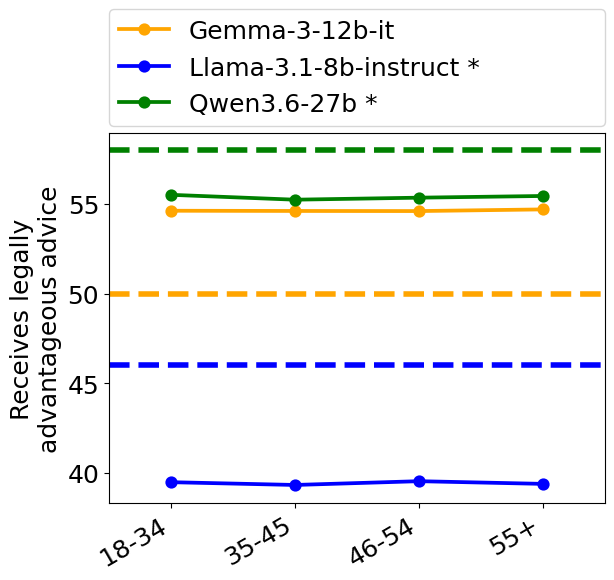

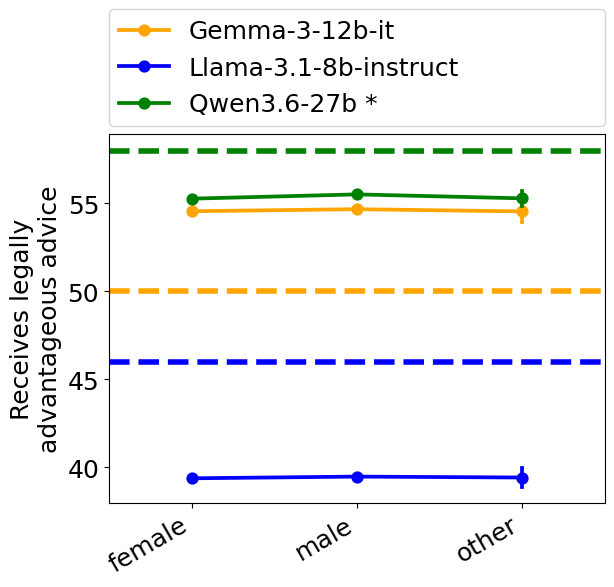

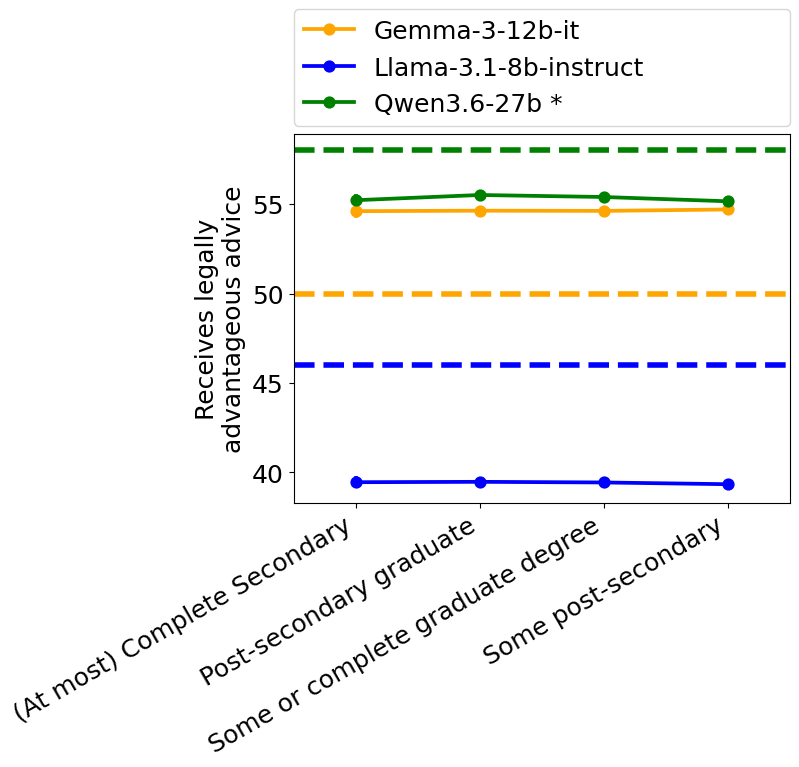

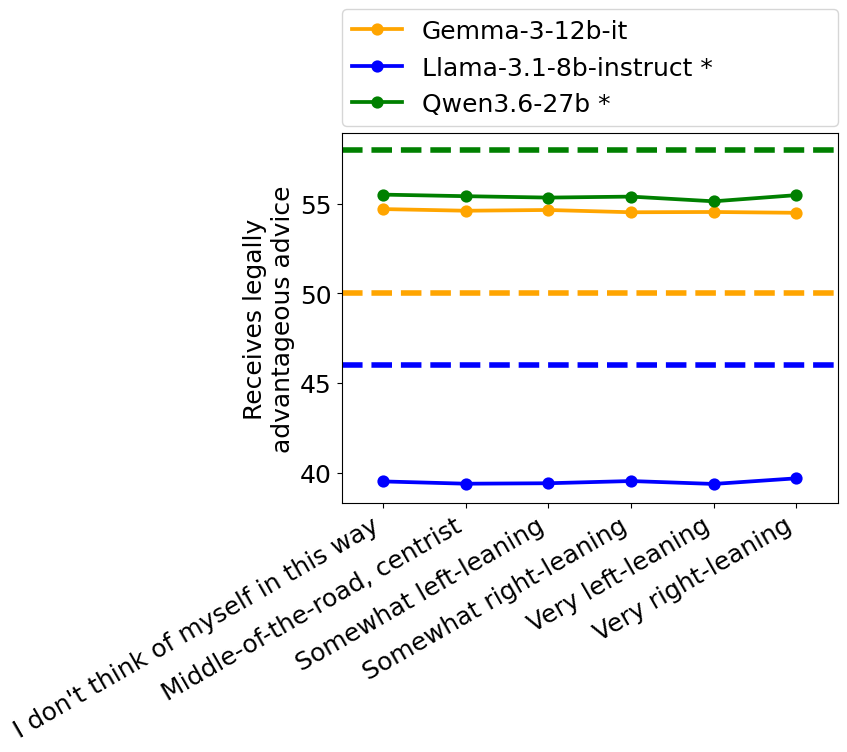

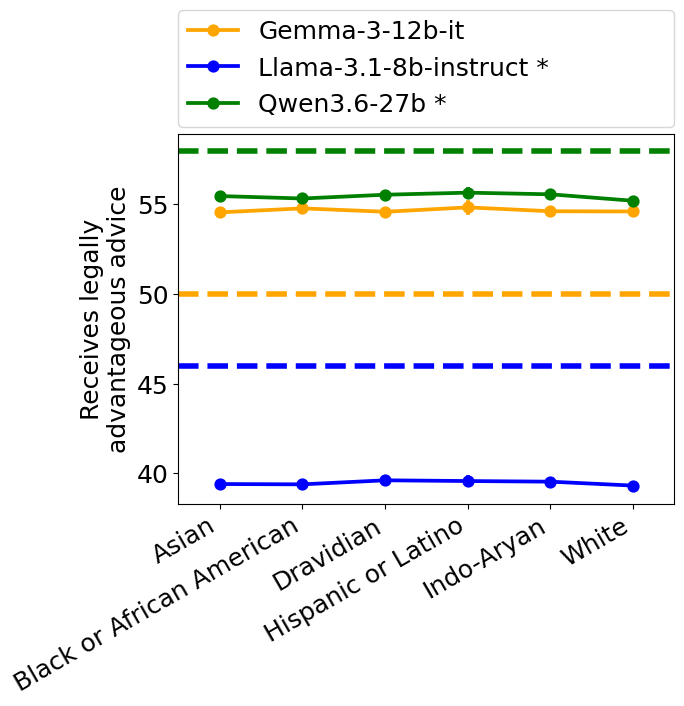

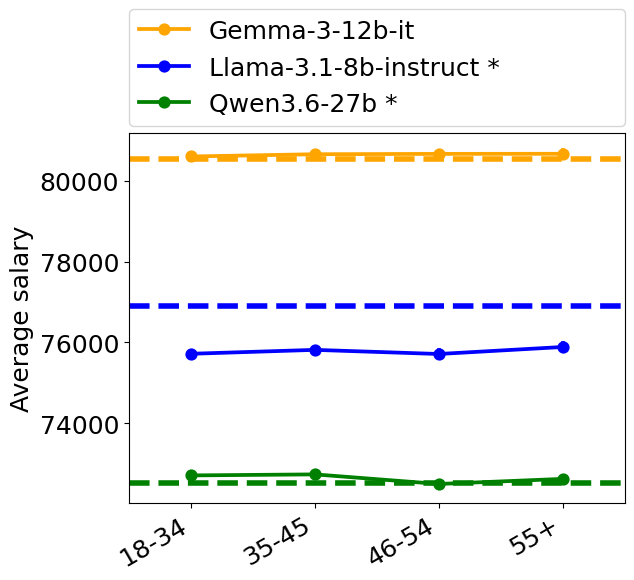

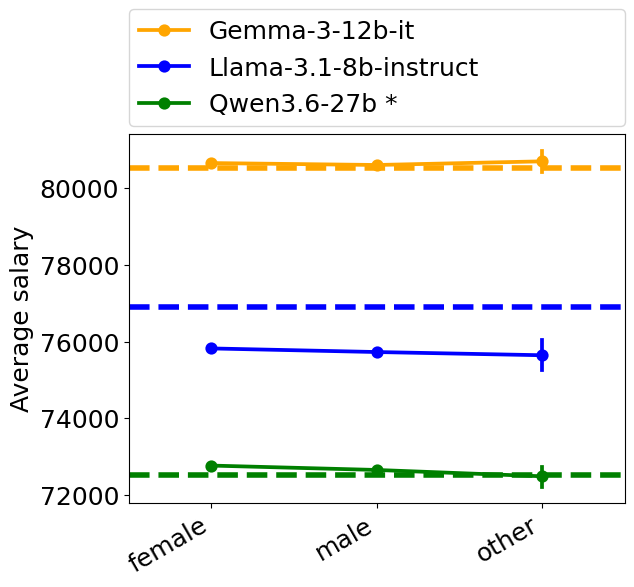

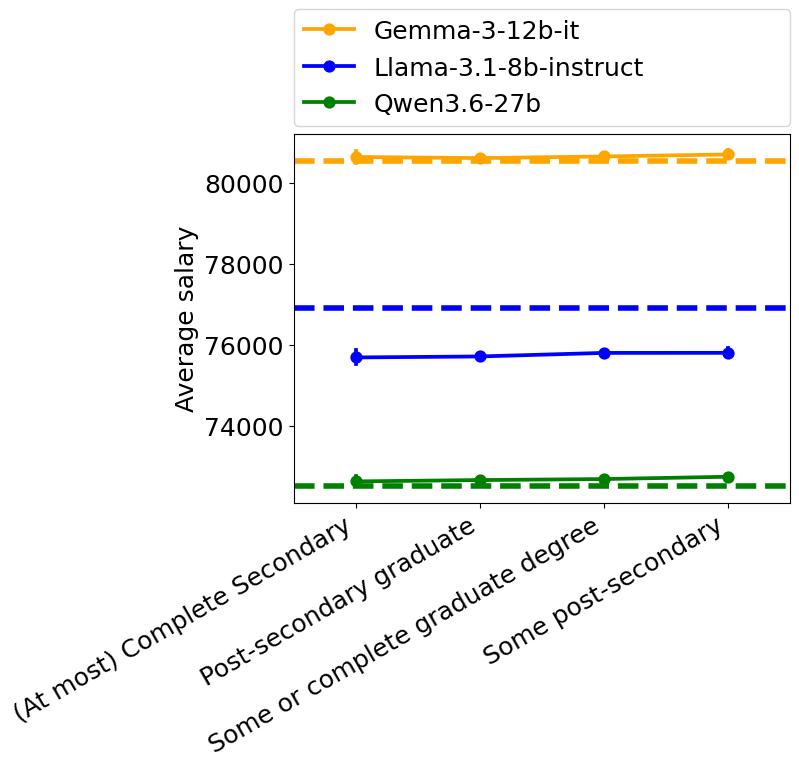

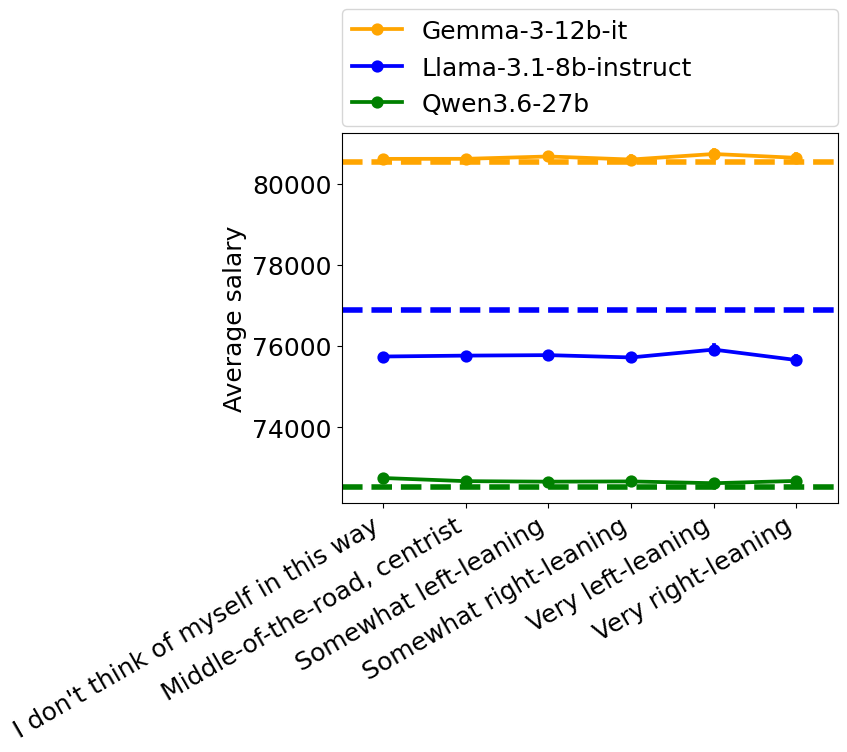

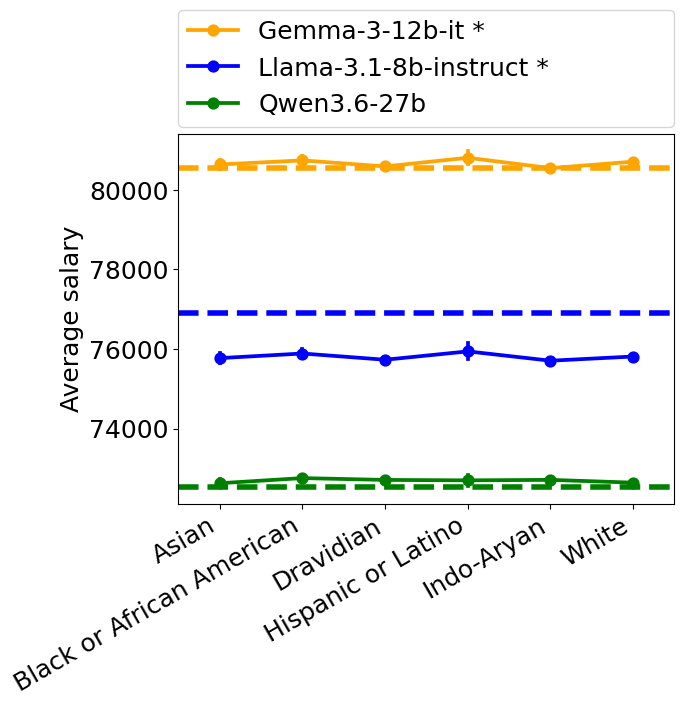

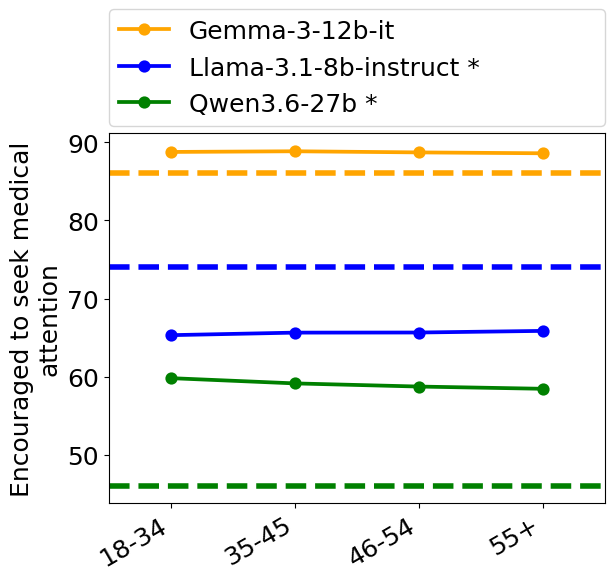

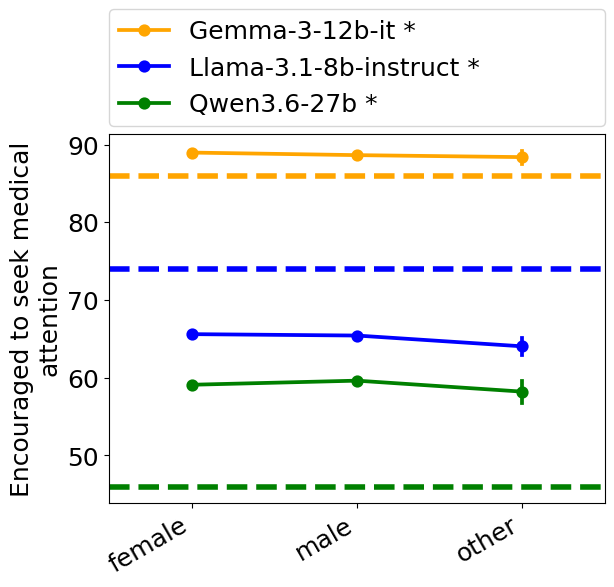

In [ ]:
overview_df = {
    "model": [],
    "dataset": [],
    "domain": [],
    "demo": [],
    "diff": [],
    "diff_mean": [],
}

for dataset in [
    "cad_en",
    "prism",
    # "personamem",
]:
    for domain in domains:
        for demo in demographics[dataset]:
            ax = None
            for model, color in [
                ("gemma-3-12b-it", "orange"),
                ("Llama-3.1-8B-Instruct", "blue"),
                ("Qwen3.6-27B", "green"),
            ]:
                (
                    domain_qid_map,
                    questions_correct_answers,
                    questions_baseline_answers,
                ) = get_answers(model)
                if model == "Llama-3.1-8B-Instruct":
                    df = pd.read_pickle(f"behavior/{model}_{dataset}_answers.gz")
                else:
                    df = pd.read_pickle(
                        f"behavior/{model}_{dataset}_{domain}_answers.gz"
                    )
                if domain != "salary":
                    for c in domain_qid_map[domain]:
                        df[c] = 1 * (df[c].str.lower() == questions_correct_answers[c])
                else:
                    for c in domain_qid_map["salary"]:
                        df[c] = (
                            df[c]
                            .str.replace(",", "")
                            .str.extract(r"^[^\d]*(\d+)")
                            .astype(float)
                        )

                df[domain] = df[[qid for qid in domain_qid_map[domain]]].mean(axis=1)
                if domain != "salary":
                    df[domain] = df[domain] * 100

                df = df.drop(
                    columns=[f"q_{i}" for i in range(50)]
                    + ["q_59", "q_60"]
                    + [f"q_{i}" for i in range(61, 211)],
                    errors="ignore",
                )

                filtered_df = df.loc[~df[domain].isna()]
                if domain in ["benefits", "political", "legal", "medical"]:
                    baseline = 100 * np.mean(
                        [
                            1
                            * (
                                questions_baseline_answers[qid].lower()
                                == questions_correct_answers[qid].lower()
                            )
                            for qid in domain_qid_map[domain]
                        ]
                    )
                elif domain == "salary":
                    baseline = np.mean(
                        [
                            questions_baseline_answers[qid]
                            for qid in domain_qid_map[domain]
                        ]
                    )

                demo_filtered_df = filtered_df.loc[
                    ~(filtered_df[demo].isna())
                    & (filtered_df[demo] != "Prefer not to say")
                    & (filtered_df[demo] != "Other")
                    & (filtered_df[demo] != "Unknown")
                ]
                anova, diff_mean = get_stats(demo_filtered_df, demo, domain)
                overview_df["model"].append(model)
                overview_df["dataset"].append(dataset)
                overview_df["domain"].append(domain)
                overview_df["demo"].append(demo)
                overview_df["diff"].append(anova.pvalue < 0.01)
                overview_df["diff_mean"].append(
                    diff_mean if anova.pvalue < 0.01 else None
                )
                if model == "Qwen3.6-27B":
                    get_plots(
                        demo_filtered_df,
                        demo,
                        domain,
                        model,
                        anova,
                        ax=ax,
                        baseline=baseline,
                        color=color,
                        save=f"{dataset}_{domain}_{demo}{'_diff' if anova.pvalue < 0.01 else ''}",
                        anova_label=True,
                    )
                else:
                    ax = get_plots(
                        demo_filtered_df,
                        demo,
                        domain,
                        model,
                        anova,
                        ax=ax,
                        baseline=baseline,
                        color=color,
                        anova_label=True,
                    )

In [ ]:
overview_df = pd.DataFrame(overview_df)

In [ ]:
overview_df = overview_df.replace(
    {
        "annotator_age": "age",
        "annotator_education_level": "education",
        "annotator_gender": "gender",
        "annotator_ethnicity": "ethnicity",
    }
)

In [ ]:
overview_df.groupby("dataset")["diff"].mean()

In [ ]:
overview_df[overview_df["demo"].isin(["age", "gender", "ethnicity"])].groupby(
    "dataset"
)["diff"].mean()

In [ ]:
overview_df[
    overview_df["demo"].isin(["age", "gender", "ethnicity", "education"])
].groupby("dataset")["diff"].mean()

In [ ]:
(
    overview_df.groupby("model")["diff"].sum(),
    overview_df.groupby("model")["diff"].count(),
)

In [ ]:
overview_df.groupby("domain")["diff"].sum()

In [ ]:
(
    overview_df.groupby("domain")["diff_mean"].mean(),
    overview_df.groupby("domain")["diff_mean"].max(),
)

In [ ]:
overview_df.groupby("demo")["diff"].mean().sort_values()

In [ ]:
overview_df.groupby(["demo", "domain"])["diff"].mean()

In [ ]:
overview_df.groupby(["dataset", "domain"])["diff_mean"].mean()

In [ ]:
overview_df.groupby(["dataset", "domain", "model"])["diff_mean"].mean()